# Разведочный анализ корреляции голов в европейских футбольных лигах

Цель данного ноутбука -- эмпирически исследовать зависимость между количеством голов, забитых хозяевами и гостями, по пяти ведущим европейским чемпионатам

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob
from scipy.stats import pearsonr, poisson
from itertools import product

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120
})


## 1. Загрузка данных

Данные загружаются из CSV-файлов (источник: football-data.co.uk) по пяти лигам. Используются только столбцы с датой, командами и итоговым счётом.

In [13]:
LEAGUES = {
    'BL':  {'name': 'Бундеслига',   'path': 'data/BL/*.csv'},
    'EPL': {'name': 'Премьер-лига', 'path': 'data/EPL/*.csv'},
    'SA':  {'name': 'Серия А',      'path': 'data/SA/*.csv'},
    'LA':  {'name': 'Ла Лига',      'path': 'data/LA/*.csv'},
    'LG1': {'name': 'Лига 1',       'path': 'data/LG1/*.csv'},
}

league_data = {}

for code_name, info in LEAGUES.items():
    files = sorted(glob.glob(info['path']))
    frames = []
    for f in files:
        df = pd.read_csv(f, usecols=lambda c: c in ['Date', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG'])
        frames.append(df)
    data = pd.concat(frames, ignore_index=True).dropna(subset=['FTHG', 'FTAG'])
    data['FTHG'] = data['FTHG'].astype(int)
    data['FTAG'] = data['FTAG'].astype(int)
    data['TotalGoals'] = data['FTHG'] + data['FTAG']
    league_data[code_name] = data
    print(f"{info['name']:15s} — {len(data)} матчей загружено ({len(files)} сезонов)")


Бундеслига      — 1458 матчей загружено (5 сезонов)
Премьер-лига    — 1821 матчей загружено (5 сезонов)
Серия А         — 1810 матчей загружено (5 сезонов)
Ла Лига         — 1800 матчей загружено (5 сезонов)
Лига 1          — 1605 матчей загружено (5 сезонов)


## 2. Описательная статистика по лигам

Сводная таблица с количеством матчей, средним числом голов дома и в гостях, общей корреляцией и её p-value.

In [14]:
rows = []

for code_name, info in LEAGUES.items():
    data = league_data[code_name]
    corr, pval = pearsonr(data['FTHG'], data['FTAG'])
    rows.append({
        'Лига': info['name'],
        'Матчей': len(data),
        'Ср. голов дома': round(data['FTHG'].mean(), 3),
        'Ср. голов в гостях': round(data['FTAG'].mean(), 3),
        'Ср. тотал': round(data['TotalGoals'].mean(), 3),
        'Корреляция (r)': round(corr, 4),
        'p-value': f'{pval:.2e}',
        'Значимость (alpha=0.05)': '✓' if pval < 0.05 else '✗'
    })

summary_table = pd.DataFrame(rows)
summary_table


,Лига,Матчей,Ср. голов дома,Ср. голов в гостях,Ср. тотал,Корреляция (r),p-value,Значимость (alpha=0.05)
0,Бундеслига,1458,1.758,1.399,3.157,-0.1392,9.38e-08,✓
1,Премьер-лига,1821,1.595,1.337,2.932,-0.1312,1.91e-08,✓
2,Серия А,1810,1.403,1.215,2.618,-0.0860,2.49e-04,✓
3,Ла Лига,1800,1.470,1.116,2.586,-0.0014,9.54e-01,✗
4,Лига 1,1605,1.539,1.273,2.812,-0.0629,1.18e-02,✓


## 3. Корреляция при низких и высоких счетах

Разбиваем матчи на две группы: низкорезультативные (тотал < 2.5) и высокорезультативные (тотал > 2.5). Ожидаем более сильную отрицательную корреляцию при низких счетах -- это ключевой эффект, который моделирует Диксон-Коулс.

In [ ]:
rows_split = []

for code_name, info in LEAGUES.items():
    data = league_data[code_name]
    
    low = data[data['TotalGoals'] < 2.5]
    high = data[data['TotalGoals'] > 2.5]
    
    corr_low, p_low = pearsonr(low['FTHG'], low['FTAG']) if len(low) > 2 else (np.nan, np.nan)
    corr_high, p_high = pearsonr(high['FTHG'], high['FTAG']) if len(high) > 2 else (np.nan, np.nan)
    corr_all, p_all = pearsonr(data['FTHG'], data['FTAG'])
    
    rows_split.append({
        'Лига': info['name'],
        'r (все)': round(corr_all, 4),
        'r (тотал < 2.5)': round(corr_low, 4),
        'p-value (< 2.5)': f'{p_low:.2e}',
        'r (тотал > 2.5)': round(corr_high, 4),
        'p-value (> 2.5)': f'{p_high:.2e}',
        'Матчей (< 2.5)': len(low),
        'Матчей (> 2.5)': len(high),
    })

split_table = pd.DataFrame(rows_split)
split_table


,Лига,r (все),r (тотал < 2.5),p-value (< 2.5),r (тотал > 2.5),p-value (> 2.5),Матчей (< 2.5),Матчей (> 2.5)
0,Бундеслига,-0.1392,-0.4597,1.65e-31,-0.5647,2.35e-75,577,881
1,Премьер-лига,-0.1312,-0.5081,1.81e-53,-0.5743,5.19e-91,796,1025
2,Серия А,-0.0860,-0.4475,2.28e-46,-0.5886,2.35e-84,917,893
3,Ла Лига,-0.0014,-0.4203,6.71e-42,-0.4982,1.41e-54,949,851
4,Лига 1,-0.0629,-0.4534,2.11e-39,-0.5312,2.80e-63,752,853


## 4. Тепловые карты частот счетов

Тепловые карты покажут, какие счета встречаются чаще или реже, чем предсказывает независимая модель Пуассона.

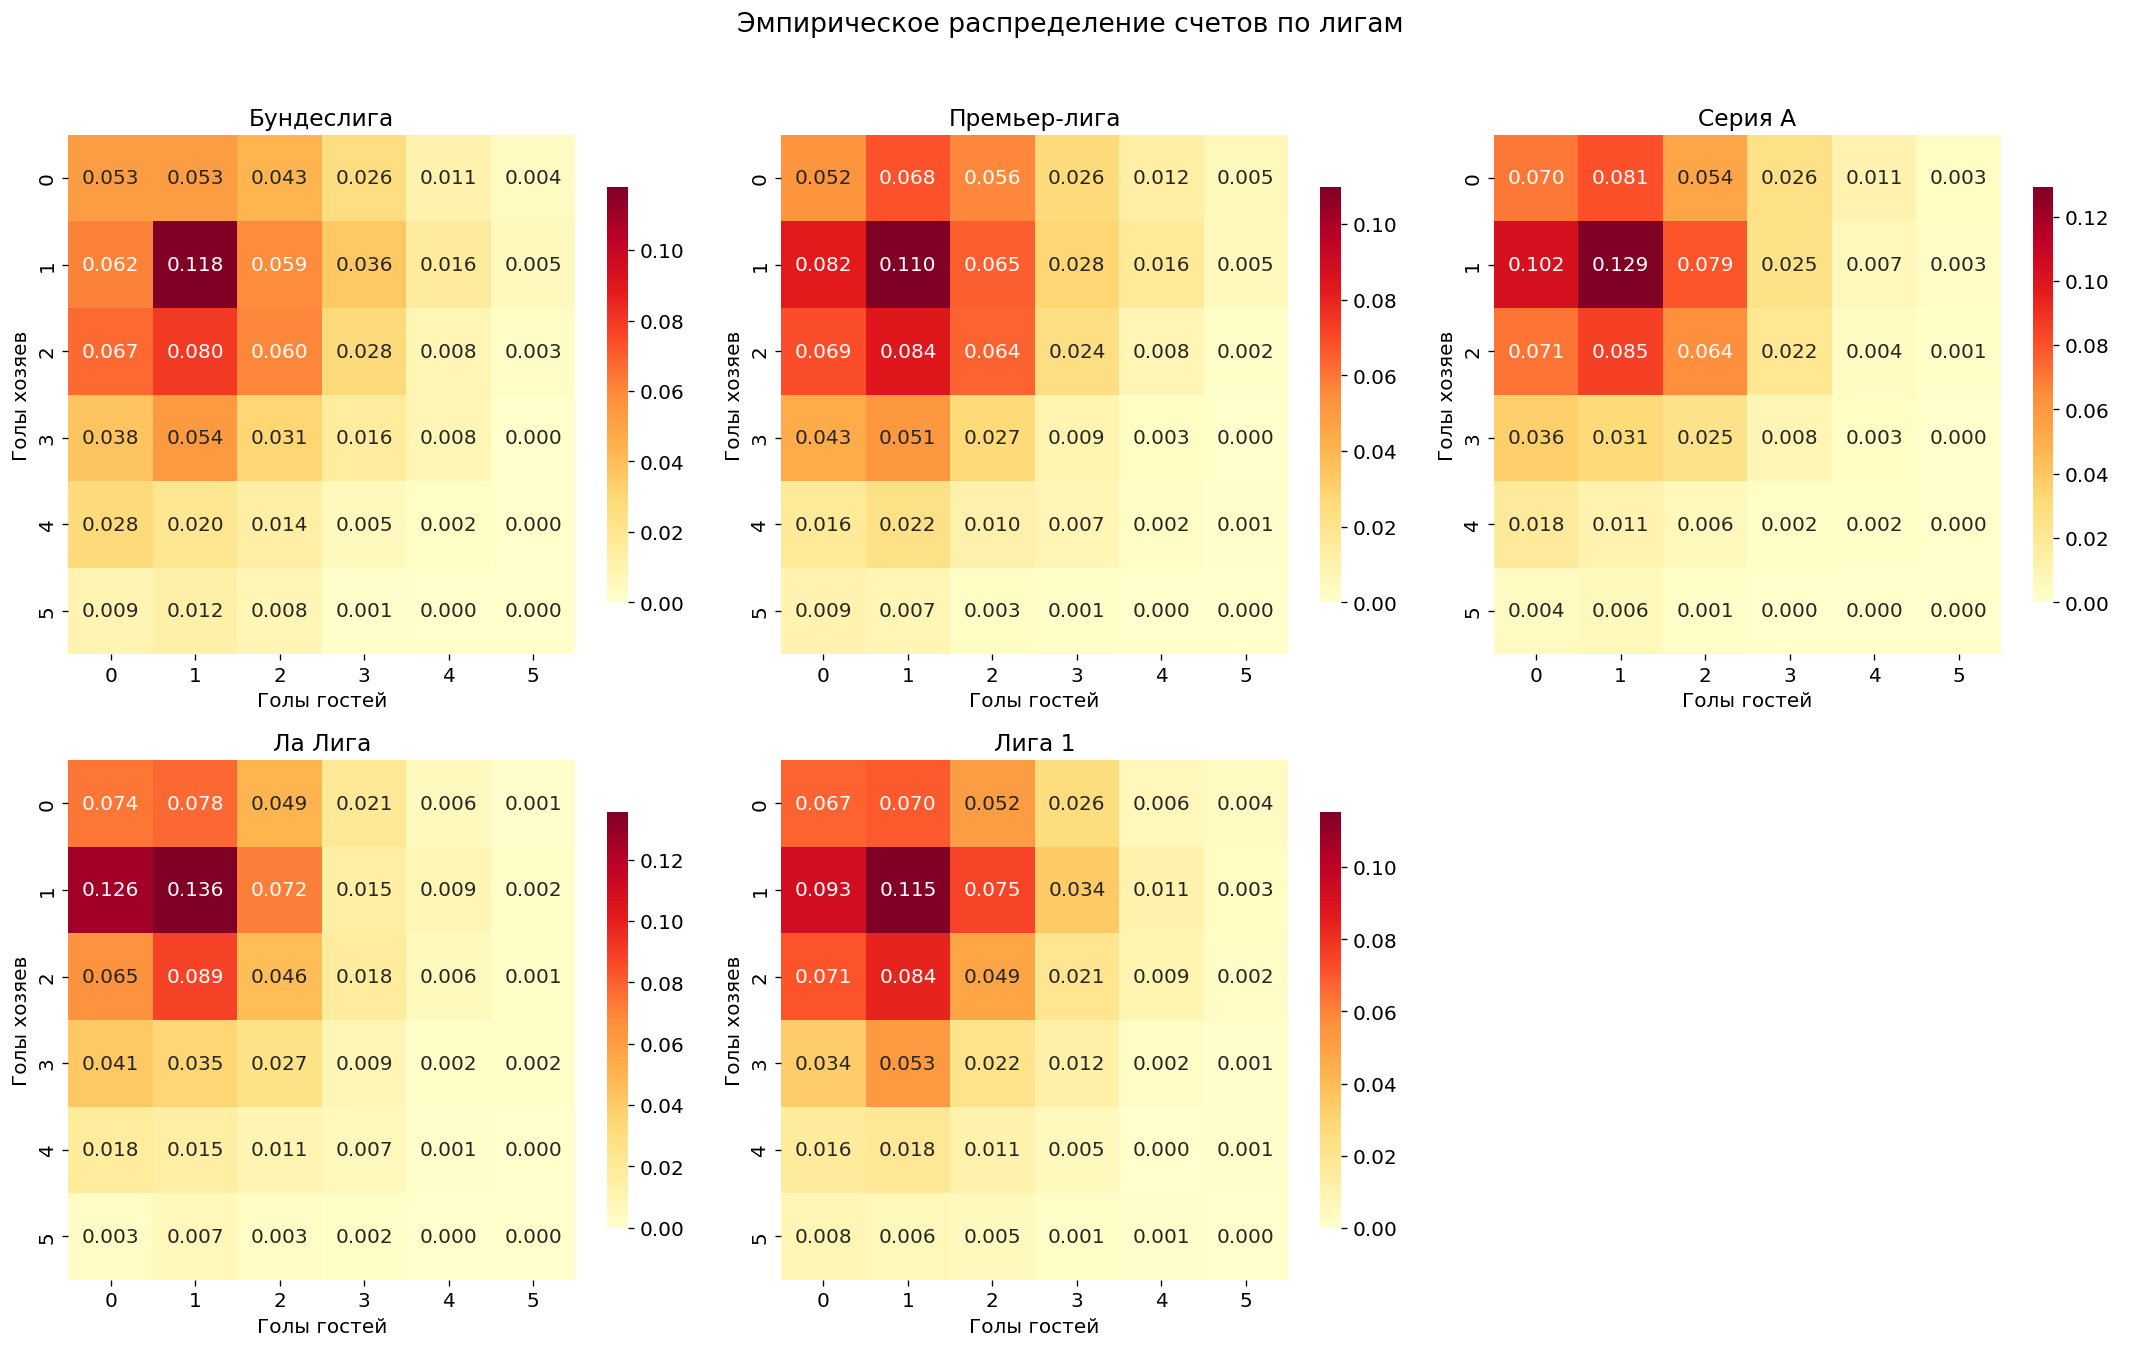

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

max_goals = 5

for idx, (code_name, info) in enumerate(LEAGUES.items()):
    ax = axes[idx]
    data = league_data[code_name]
    
    # Эмпирическая матрица частот
    freq_matrix = np.zeros((max_goals + 1, max_goals + 1))
    for _, row in data.iterrows():
        h, a = int(row['FTHG']), int(row['FTAG'])
        if h <= max_goals and a <= max_goals:
            freq_matrix[h, a] += 1
    freq_matrix /= len(data)
    
    sns.heatmap(freq_matrix, annot=True, fmt='.3f', cmap='YlOrRd',
                xticklabels=range(max_goals + 1),
                yticklabels=range(max_goals + 1),
                ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title(info['name'])
    ax.set_xlabel('Голы гостей')
    ax.set_ylabel('Голы хозяев')

# Убираем пустой 6-й subplot
axes[5].axis('off')

plt.suptitle('Эмпирическое распределение счетов по лигам', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('score_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Сравнение наблюдаемых и ожидаемых частот

Для каждой лиги сравниваем наблюдаемые частоты ключевых счетов (0:0, 1:0, 0:1, 1:1) с ожидаемыми при независимости голов. Ожидаемая частота при независимости: P(x, y) = P(x) * P(y).

Это центральная таблица, обосновывающая применение модели Диксона-Коулса: если наблюдаемые частоты систематически превышают ожидаемые при низких счетах -- значит, независимость нарушена.

In [ ]:
key_scores = [(0, 0), (1, 0), (0, 1), (1, 1)]

rows_obs_exp = []

for code_name, info in LEAGUES.items():
    data = league_data[code_name]
    n = len(data)
    
    home_dist = data['FTHG'].value_counts(normalize=True)
    away_dist = data['FTAG'].value_counts(normalize=True)
    
    for (h, a) in key_scores:
        observed = len(data[(data['FTHG'] == h) & (data['FTAG'] == a)]) / n
        expected = home_dist.get(h, 0) * away_dist.get(a, 0)
        ratio = observed / expected if expected > 0 else np.nan
        
        rows_obs_exp.append({
            'Лига': info['name'],
            'Счёт': f'{h}:{a}',
            'Наблюд. частота': round(observed, 4),
            'Ожид. (независ.)': round(expected, 4),
            'Отношение': round(ratio, 3),
        })

obs_exp_table = pd.DataFrame(rows_obs_exp)

pivot = obs_exp_table.pivot_table(
    index='Лига', columns='Счёт', values='Отношение'
)[['0:0', '1:0', '0:1', '1:1']]

print("Отношение наблюдаемой частоты к ожидаемой при независимости:")
print()
pivot


Отношение наблюдаемой частоты к ожидаемой при независимости:



Счёт,0:0,1:0,0:1,1:1
Лига,,,,
Бундеслига,1.029,0.776,0.799,1.152
Ла Лига,0.978,1.064,0.936,1.044
Лига 1,1.019,0.956,0.884,0.986
Премьер-лига,0.845,0.971,0.888,1.043
Серия А,0.937,0.973,0.945,1.079


## 5.1 Статистическая значимость отклонений (hi^2-тест)

Таблица отношений показывает направление отклонений, но не отвечает на вопрос: значимы ли они статистически, или это просто шум из-за конечного размера выборки. Применим hi^2-тест для каждого счёта в каждой лиге

Нулевая гипотеза H_0: голы хозяев и гостей независимы, то есть P(x, y) = P(x) * P(y)
Альтернативная гипотеза H_1: наблюдаемая частота данного счёта значимо отличается от ожидаемой при независимости

Для каждой пары (лига, счёт) вычисляется статистика hi^2 = N * (p_obs − p_exp)^2 / p_exp и соответствующий p-value

Дополнительно проведем общий hi^2-тест независимости по полной матрице счетов для каждой лиги

In [ ]:
from scipy.stats import chi2, chi2_contingency

key_scores = [(0, 0), (1, 0), (0, 1), (1, 1)]
chi2_rows = []

for code_name, info in LEAGUES.items():
    data = league_data[code_name]
    n = len(data)
    
    home_dist = data['FTHG'].value_counts(normalize=True)
    away_dist = data['FTAG'].value_counts(normalize=True)
    
    for (h, a) in key_scores:
        observed_count = len(data[(data['FTHG'] == h) & (data['FTAG'] == a)])
        p_exp = home_dist.get(h, 0) * away_dist.get(a, 0)
        expected_count = n * p_exp
        
        if expected_count > 0:
            chi2_stat = (observed_count - expected_count)**2 / expected_count
            p_val = 1 - chi2.cdf(chi2_stat, df=1)
        else:
            chi2_stat, p_val = np.nan, np.nan
        
        chi2_rows.append({
            'Лига': info['name'],
            'Счёт': f'{h}:{a}',
            'Набл.': observed_count,
            'Ожид.': round(expected_count, 1),
            'hi^2': round(chi2_stat, 3),
            'p-value': f'{p_val:.4f}',
            'Значимо': 'y' if p_val < 0.05 else 'n'
        })

chi2_table = pd.DataFrame(chi2_rows)
print('Поточечный hi^2-тест для низовых счетов:')
print('(H_0: наблюдаемая частота = ожидаемой при независимости)')
print()
chi2_table


Поточечный hi^2тест для низовых счетов:
(H_0: наблюдаемая частота = ожидаемой при независимости)



,Лига,Счёт,Набл.,Ожид.,hi^2,p-value,Значимо
0,Бундеслига,0:0,77,74.9,0.062,0.8039,n
1,Бундеслига,1:0,90,116.0,5.825,0.0158,y
2,Бундеслига,0:1,77,96.3,3.876,0.0490,y
3,Бундеслига,1:1,172,149.3,3.463,0.0627,n
4,Премьер-лига,0:0,95,112.4,2.685,0.1013,n
5,Премьер-лига,1:0,150,154.4,0.128,0.7210,n
6,Премьер-лига,0:1,124,139.6,1.737,0.1875,n
7,Премьер-лига,1:1,200,191.8,0.349,0.5549,n
8,Серия А,0:0,127,135.5,0.536,0.4640,n
9,Серия А,1:0,185,190.2,0.143,0.7050,n


In [ ]:
print('Общий hi^2-тест независимости (contingency table, счета 0..5 на 0..5):')
print('(H_0: количество голов хозяев и гостей независимы)')
print()

max_g = 5
cont_rows = []

for code_name, info in LEAGUES.items():
    data = league_data[code_name]
    
    contingency = np.zeros((max_g + 1, max_g + 1), dtype=int)
    for _, row in data.iterrows():
        h = min(int(row['FTHG']), max_g)
        a = min(int(row['FTAG']), max_g)
        contingency[h, a] += 1
    
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency)
    
    cont_rows.append({
        'Лига': info['name'],
        'hi^2': round(chi2_stat, 2),
        'df': dof,
        'p-value': f'{p_val:.2e}',
        'Значимо': 'y' if p_val < 0.05 else 'n'
    })

cont_table = pd.DataFrame(cont_rows)
cont_table


Общий hi^2-тест независимости (contingency table, счета 0..5 на 0..5):
(H_0: количество голов хозяев и гостей независимы)



,Лига,hi^2,df,p-value,Значимо
0,Бундеслига,57.91,25,2.02e-04,y
1,Премьер-лига,55.76,25,3.91e-04,y
2,Серия А,45.56,25,7.21e-03,y
3,Ла Лига,33.91,25,1.10e-01,n
4,Лига 1,19.06,25,7.94e-01,n


## 6. Визуализация: наблюдаемые vs ожидаемые частоты


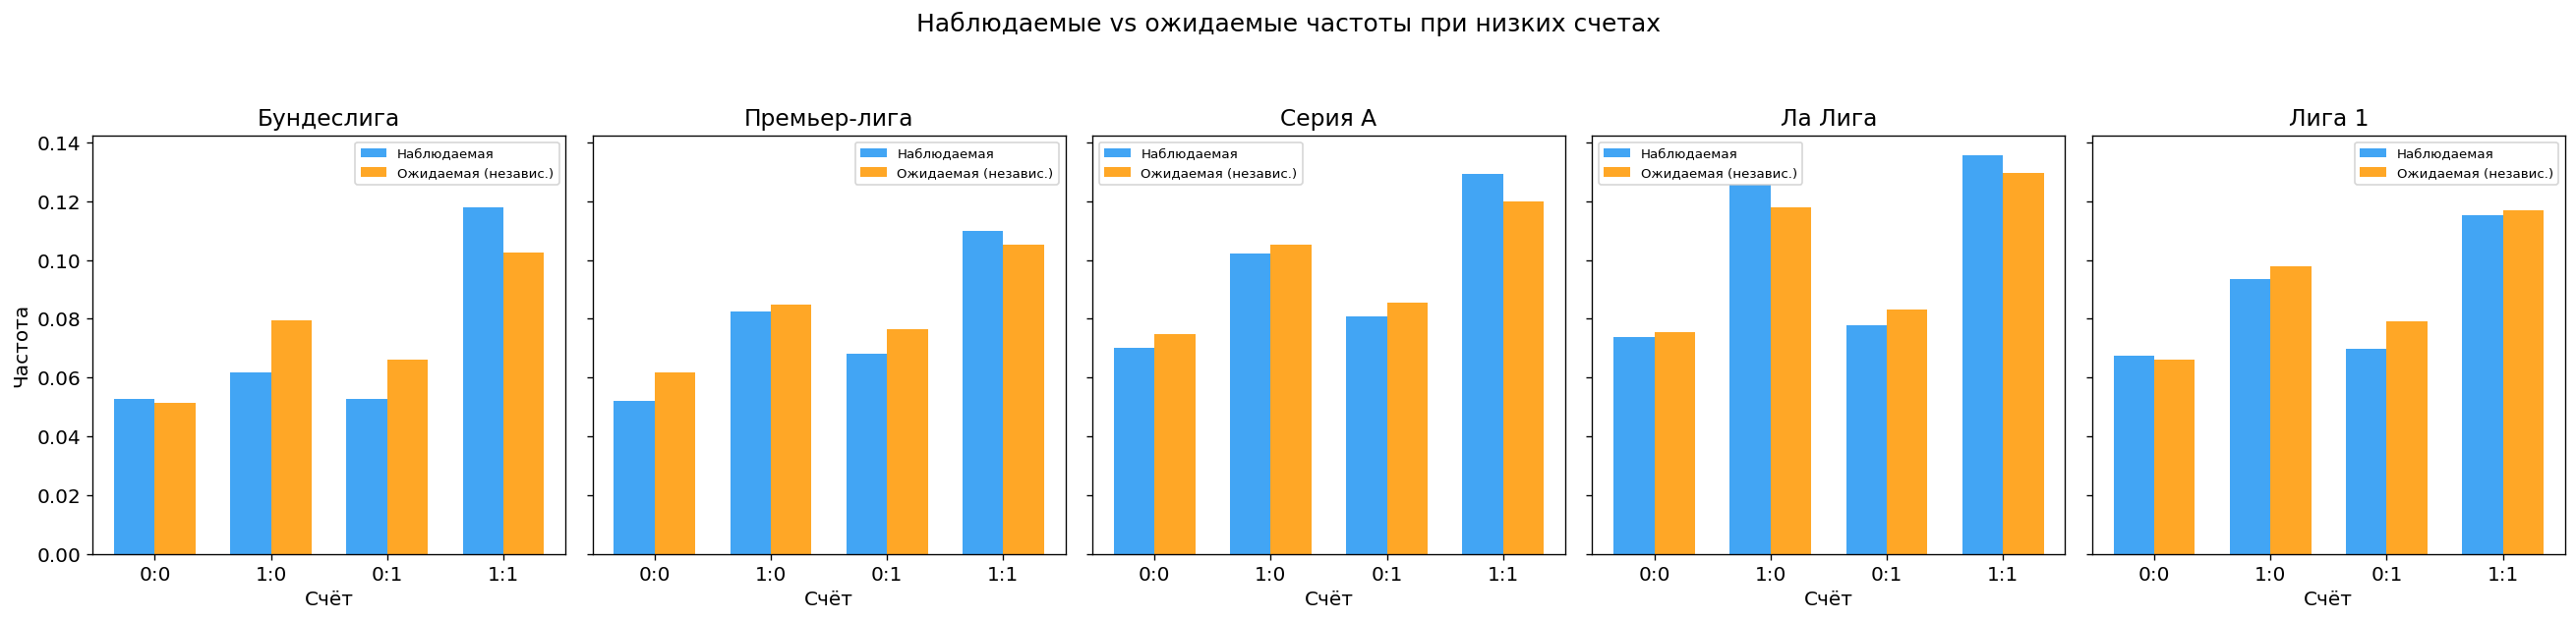

In [20]:
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
score_labels = ['0:0', '1:0', '0:1', '1:1']

for idx, (code_name, info) in enumerate(LEAGUES.items()):
    ax = axes[idx]
    league_rows = obs_exp_table[obs_exp_table['Лига'] == info['name']]
    
    x = np.arange(len(score_labels))
    width = 0.35
    
    obs_vals = league_rows['Наблюд. частота'].values
    exp_vals = league_rows['Ожид. (независ.)'].values
    
    bars1 = ax.bar(x - width/2, obs_vals, width, label='Наблюдаемая', color='#2196F3', alpha=0.85)
    bars2 = ax.bar(x + width/2, exp_vals, width, label='Ожидаемая (независ.)', color='#FF9800', alpha=0.85)
    
    ax.set_title(info['name'])
    ax.set_xticks(x)
    ax.set_xticklabels(score_labels)
    ax.set_xlabel('Счёт')
    if idx == 0:
        ax.set_ylabel('Частота')
    ax.legend(fontsize=8)

plt.suptitle('Наблюдаемые vs ожидаемые частоты при низких счетах', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('obs_vs_exp_low_scores.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Scatter-плоты с jitter


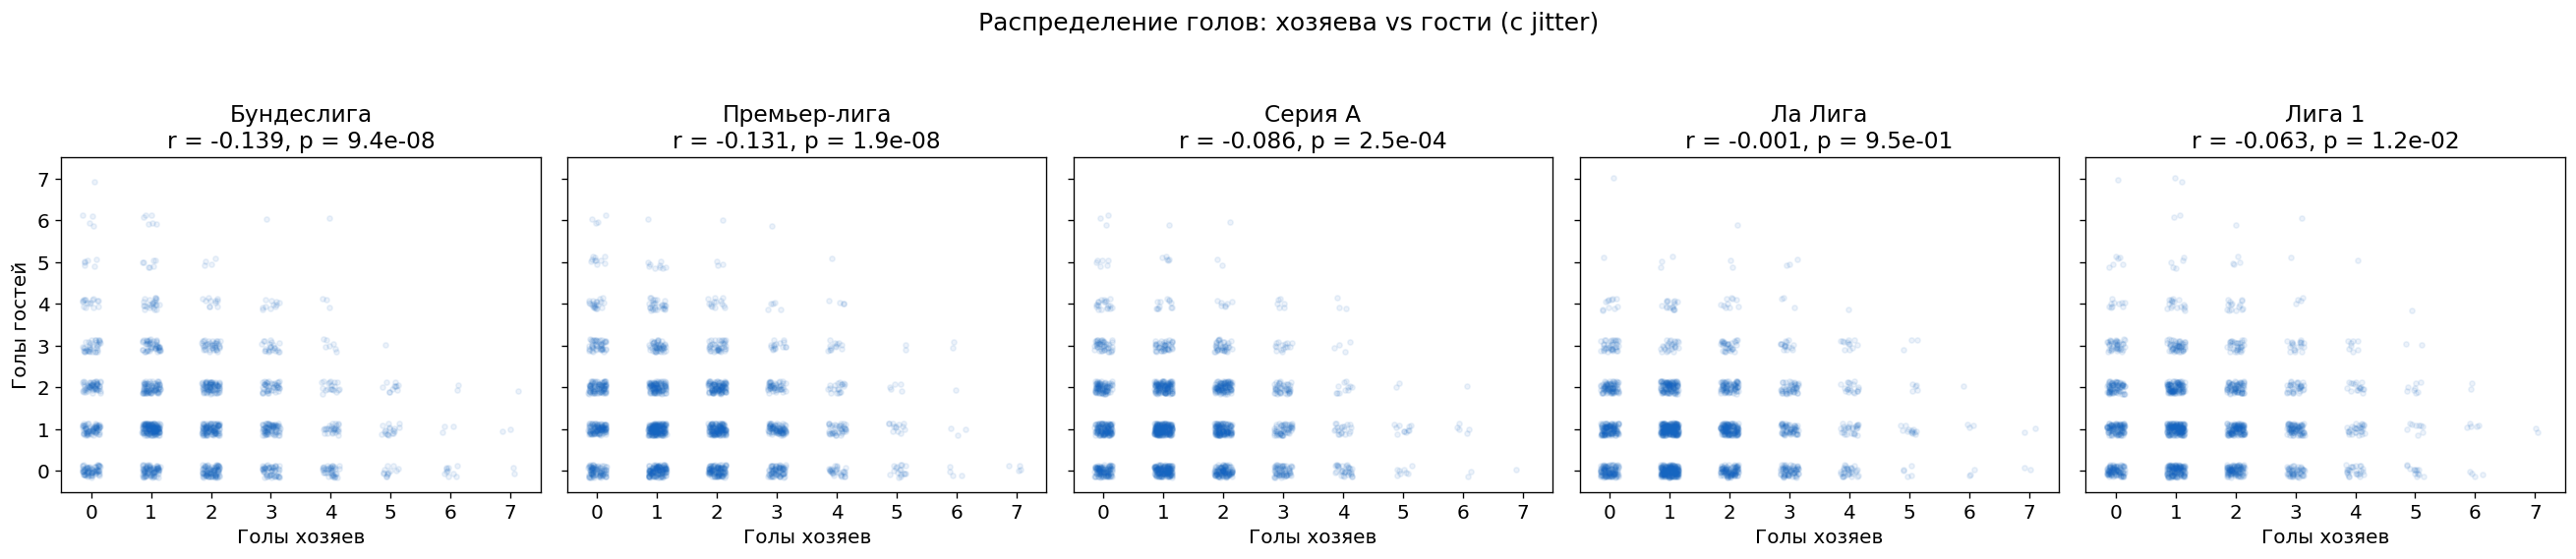

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)

for idx, (code_name, info) in enumerate(LEAGUES.items()):
    ax = axes[idx]
    data = league_data[code_name]
    corr, pval = pearsonr(data['FTHG'], data['FTAG'])

    jitter_strength = 0.15
    x = data['FTHG'] + np.random.uniform(-jitter_strength, jitter_strength, len(data))
    y = data['FTAG'] + np.random.uniform(-jitter_strength, jitter_strength, len(data))
    
    ax.scatter(x, y, alpha=0.08, s=10, color='#1565C0')
    ax.set_title(f"{info['name']}\nr = {corr:.3f}, p = {pval:.1e}")
    ax.set_xlabel('Голы хозяев')
    if idx == 0:
        ax.set_ylabel('Голы гостей')
    ax.set_xlim(-0.5, 7.5)
    ax.set_ylim(-0.5, 7.5)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.suptitle('Распределение голов: хозяева vs гости (с jitter)', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('scatter_goals_jitter.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Распределение тотала голов vs распределение Пуассона

Сравниваем эмпирическое распределение суммарного числа голов с теоретическим распределением Пуассона (λ = среднее тотала). Отклонения указывают на сверхдисперсию — ещё одно ограничение базовой модели.

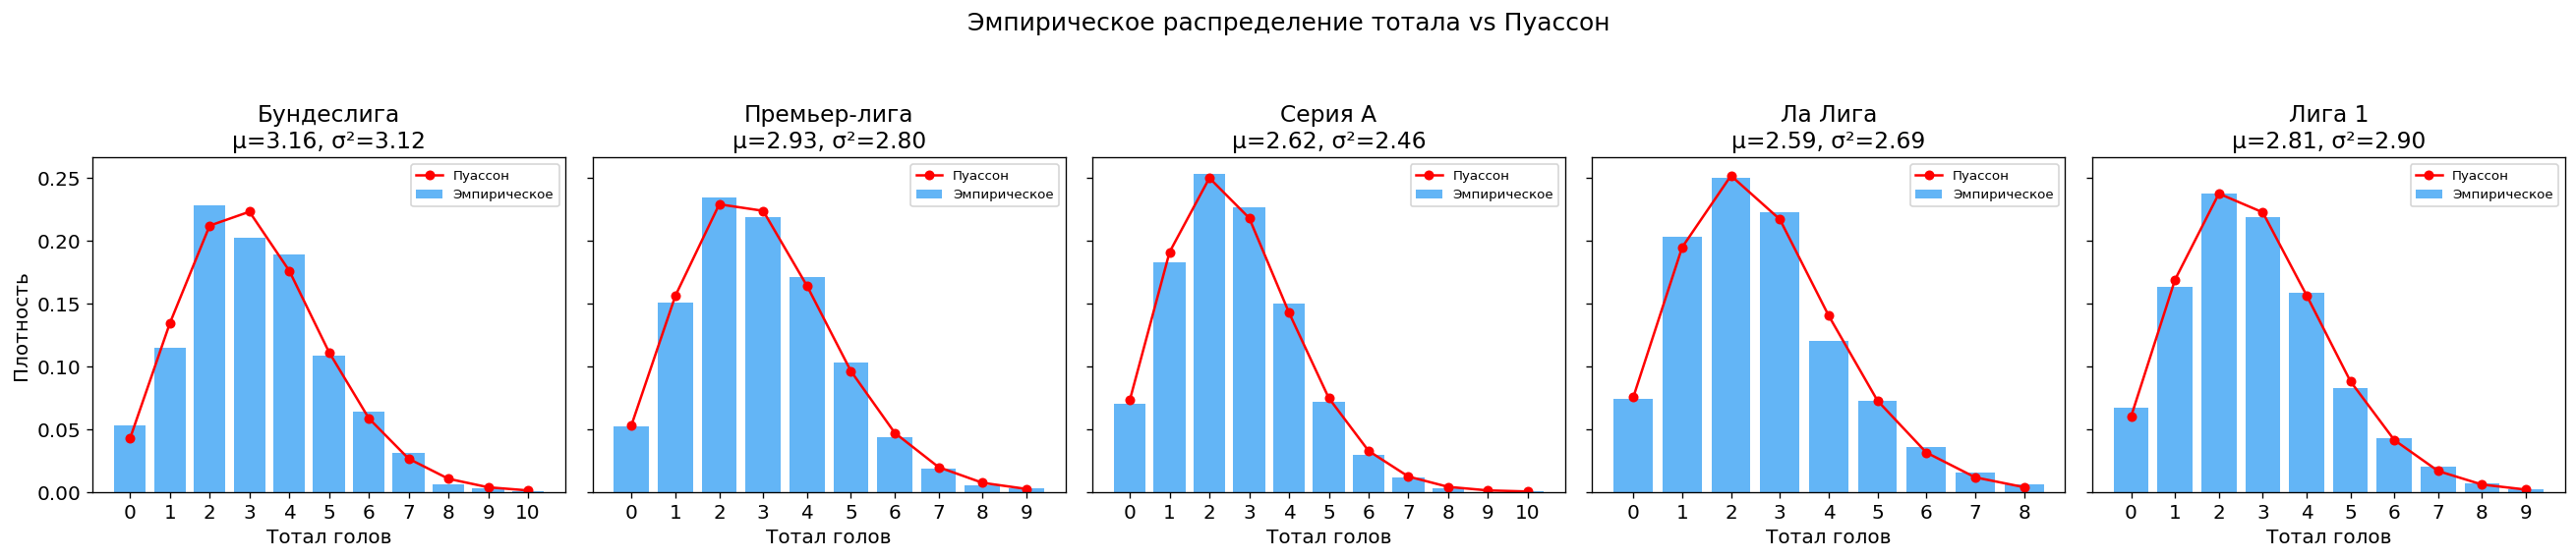


Проверка эквидисперсии (σ²/μ = 1 для Пуассона):
  Бундеслига     : μ = 3.157, σ² = 3.117, σ²/μ = 0.987
  Премьер-лига   : μ = 2.932, σ² = 2.799, σ²/μ = 0.955
  Серия А        : μ = 2.618, σ² = 2.460, σ²/μ = 0.940
  Ла Лига        : μ = 2.586, σ² = 2.690, σ²/μ = 1.040
  Лига 1         : μ = 2.812, σ² = 2.897, σ²/μ = 1.030


In [22]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)

for idx, (code_name, info) in enumerate(LEAGUES.items()):
    ax = axes[idx]
    data = league_data[code_name]
    totals = data['TotalGoals']
    
    mean_total = totals.mean()
    var_total = totals.var()
    max_total = min(int(totals.max()), 10)
    
    # Эмпирическое распределение
    bins = np.arange(0, max_total + 2) - 0.5
    counts, _ = np.histogram(totals, bins=bins, density=True)
    x_vals = np.arange(0, max_total + 1)
    
    ax.bar(x_vals, counts, alpha=0.7, color='#2196F3', label='Эмпирическое')
    
    # Теоретическое распределение Пуассона
    poisson_probs = [poisson.pmf(k, mean_total) for k in x_vals]
    ax.plot(x_vals, poisson_probs, 'ro-', markersize=5, linewidth=1.5, label='Пуассон')
    
    ax.set_title(f"{info['name']}\nμ={mean_total:.2f}, σ²={var_total:.2f}")
    ax.set_xlabel('Тотал голов')
    if idx == 0:
        ax.set_ylabel('Плотность')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

plt.suptitle('Эмпирическое распределение тотала vs Пуассон', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig('total_goals_vs_poisson.png', dpi=150, bbox_inches='tight')
plt.show()

# Таблица дисперсия/среднее
print("\nПроверка эквидисперсии (σ²/μ = 1 для Пуассона):")
for code_name, info in LEAGUES.items():
    data = league_data[code_name]
    mu = data['TotalGoals'].mean()
    var = data['TotalGoals'].var()
    print(f"  {info['name']:15s}: μ = {mu:.3f}, σ² = {var:.3f}, σ²/μ = {var/mu:.3f}")


## 9. Выводы разведочного анализа

**Основные результаты:**

1. **Корреляция голов отрицательна во всех лигах** -- от -0.139 (Бундеслига) до -0.001 (Ла Лига). Это означает, что высокая результативность одной команды слабо связана с низкой результативностью другой, а предположение о независимости голов не подтверждается

2. **Корреляция значительно сильнее при низких счетах** -- разбивка по тоталу показывает, что при тотале < 2.5 корреляция в 2-5 раз сильнее, чем при тотале > 2.5. Это прямо мотивирует использование модели Диксона-Коулса с поправкой для счетов 0:0, 1:0, 0:1, 1:1.

3. **Счета 0:0 и 1:1 наблюдаются чаще, чем предсказывает модель независимости** - отношение наблюдаемой частоты к ожидаемой систематически > 1 для этих счетов.

4. **Наблюдается умеренная сверхдисперсия** -- отношение σ²/μ > 1 для тотала голов, что указывает на ограничение эквидисперсии распределения Пуассона.

5. **Поточечный hi^2-тест показал**, что отклонения наблюдаемых частот от ожидаемых для отдельных низовых счетов (0:0, 1:0, 0:1, 1:1) в подавляющем большинстве случаев статистически незначимы (18 из 20 проверок). Значимые отклонения обнаружены только в Бундеслиге для счетов 1:0 и 0:1, причём в обоих случаях наблюдаемая частота ниже ожидаемой.

6. **Общий hi^2-тест по полной матрице сопряжённости выявил** значимое отклонение от независимости в трёх из пяти лиг (Бундеслига, Премьер-лига, Серия А). Это подтверждает наличие структурной зависимости, распределённой по множеству счетов, а не сконцентрированной в отдельных ячейках. Для Ла Лиги и Лиги 1 гипотеза независимости не отвергается.

7. **Полученные результаты мотивируют** использование моделей с корреляционной поправкой, однако указывают на то, что эффективность таких моделей может существенно различаться между лигами. Наибольший прирост качества от модели Диксона-Коулса ожидается в Бундеслиге и Премьер-лиге, тогда как для Ла Лиги базовая пуассоновская модель может оказаться достаточной.